In [1]:
from _plotting import plot_embedding_methods
import polars as pl
import tempfile
from glob import glob
from pathlib import Path
from _analysis import load_jsons, align_mrm_lists

%load_ext autoreload
%autoreload 2

In [24]:
mimicry_i_path = "/home/weissl/Projects/SMOO/defaults/mimicry/runs/runs/*_custom_class*"
mimicry_i_origins = glob(mimicry_i_path + "/origin*.png")
mimicry_i_targets = glob(mimicry_i_path + "/best*.png")

hynea_i_path = "/home/weissl/Projects/SMOO/defaults/hynea/runs/*/*_custom_1*"
hynea_i_origins = glob(hynea_i_path + "/origin*.png")
hynea_i_targets = glob(hynea_i_path + "/taget*.png")

mrm_path = "/home/weissl/PycharmProjects/genai_tigs/experiments/imagenet_experiments/imagenet_sd/ conditional_sd/imagenet_sd/test_"
mrm_jsons = load_jsons(glob(mrm_path + "/*/*.json"))
mrm_origins, mrm_targets = align_mrm_lists(glob(mrm_path + "/*.png"), glob(mrm_path + "/**/*.npy"))

In [25]:
path = Path("imagenet.parquet")
if not path.exists():
    df = pl.read_parquet('hf://datasets/ILSVRC/imagenet-1k/data/validation-*.parquet')
    df = df.filter(pl.col("label").is_in([850, 963]))
    df = df.with_columns([
        pl.col("image").struct.field("bytes").alias("image_bytes"),
        pl.col("image").struct.field("path").alias("image_filename")
    ])
    df.write_parquet(path)
else:
    df = pl.read_parquet(path)

tmp_dir = Path(tempfile.mkdtemp())
paths = []
for row in df.iter_rows(named=True):
    path = tmp_dir / row["image_filename"]
    with open(path, "wb") as f:
        f.write(row["image_bytes"])
    paths.append(str(path))

# Add paths as a new column
df = df.with_columns(pl.Series("image_path", paths))

In [26]:
density = {
    "Teddy": df.filter(pl.col("label") == 850)["image_path"].to_list(),
    "Pizza": df.filter(pl.col("label") == 963)["image_path"].to_list(),
}

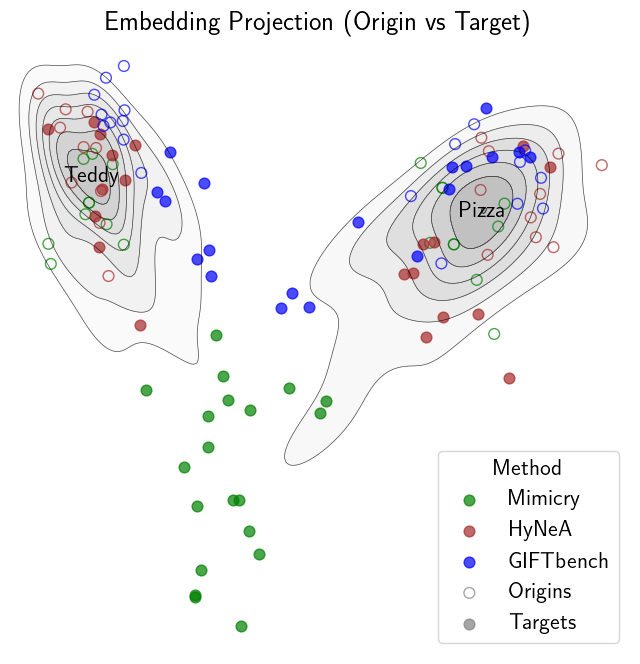

In [29]:
# Check embedding projection between teddy and pizza
filtered_mio, filtered_mit = [p for p in mimicry_i_origins if "class_850" in p or "class_963" in p], [p for p in mimicry_i_targets if "class_850" in p or "class_963" in p]
filtered_hio, filtered_hit = [p for p in hynea_i_origins if "class_850" in p or "class_963" in p], [p for p in hynea_i_targets if "class_850" in p or "class_963" in p]

inpt = {
    "Mimicry": (filtered_mio, filtered_mit),
    "HyNeA": (filtered_hio, filtered_hit),
    "GIFTbench": (mrm_origins, mrm_targets),
}

plot_embedding_methods(inpt, density=density, fig_name="embedding_imagenet")

In [30]:
hynea_c_path = "/home/weissl/Projects/SMOO/defaults/hynea/runs/*/*_custom_b*"
hynea_c_origins = glob(hynea_c_path + "/origin*.png")
hynea_c_targets = glob(hynea_c_path + "/taget*.png")


mimicry_c_path = "/home/weissl/Projects/SMOO/defaults/mimicry/runs/runs/*_custom_b*"
mimicry_c_origins = glob(mimicry_c_path + "/origin*.png")
mimicry_c_targets = glob(mimicry_c_path + "/best*.png")

In [31]:
path = Path("celeba.parquet")
if not path.exists():
    df = pl.read_parquet('hf://datasets/flwrlabs/celeba/img_align+identity+attr/valid-00000-of-00003.parquet').sample(n=2000)
    df = df.with_columns([
        pl.col("image").struct.field("bytes").alias("image_bytes"),
        pl.col("image").struct.field("path").alias("image_filename")
    ])
    df.write_parquet(path)
else:
    df = pl.read_parquet(path)

tmp_dir = Path(tempfile.mkdtemp())
paths = []
for row in df.iter_rows(named=True):
    path = tmp_dir / row["image_filename"]
    with open(path, "wb") as f:
        f.write(row["image_bytes"])
    paths.append(str(path))

df = df.with_columns(pl.Series("image_path", paths))
density = {
    "False": df.filter(pl.col("Male") == "false")["image_path"].sample(100).to_list(),
    "True": df.filter(pl.col("Male") == "true")["image_path"].sample(100).to_list(),
}

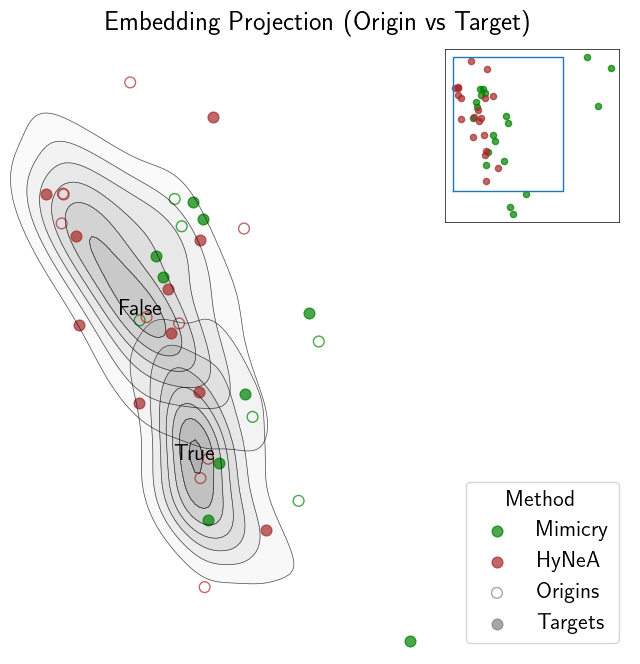

In [43]:
# Check embedding
class_id = 20
filtered_mco, filtered_mct = [p for p in mimicry_c_origins if f"class_{class_id}" in p],  [p for p in mimicry_c_targets if f"class_{class_id}" in p]
filtered_hco, filtered_hct = [p for p in hynea_c_origins if f"class_{class_id}" in p], [p for p in hynea_c_targets if f"class_{class_id}" in p]

inpt = {
    "Mimicry": (filtered_mco, filtered_mct),
    "HyNeA": (filtered_hco, filtered_hct),
}
plot_embedding_methods(inpt, fig_name="embedding_celebA", density=density, crop_outliers=(0,99,1,100))